In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline


In [70]:
df_index=pd.read_csv("economic_index.csv")

In [71]:
df_index.head()

,year,month,interest_rate,unemployment_rate,index_price
0,2017,12,2.75,5.3,1464
1,2017,11,2.50,5.3,1394
2,2017,10,2.50,5.3,1357
3,2017,9,2.50,5.3,1293
4,2017,8,2.50,5.4,1256


In [72]:
# drop unnecessary columns (year and month)
df_index.drop(columns=["year","month"],inplace=True)


In [73]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [74]:
## check null values
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

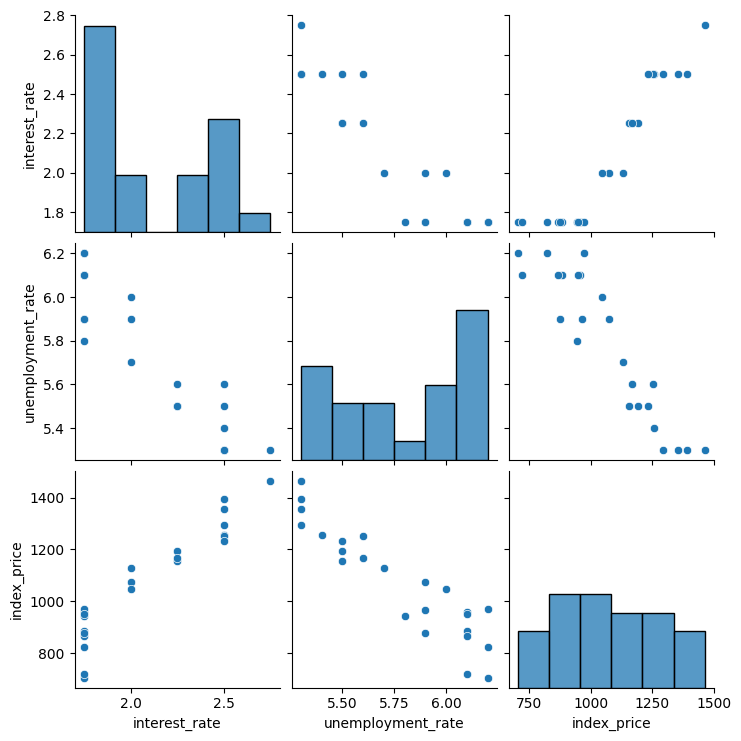

In [75]:
## Visualisation
import seaborn as sns
sns.pairplot(df_index)

In [76]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935730
unemployment_rate,-0.925814,1.000000,-0.921999
index_price,0.935730,-0.921999,1.000000


Text(0, 0.5, 'unemployment_rate')

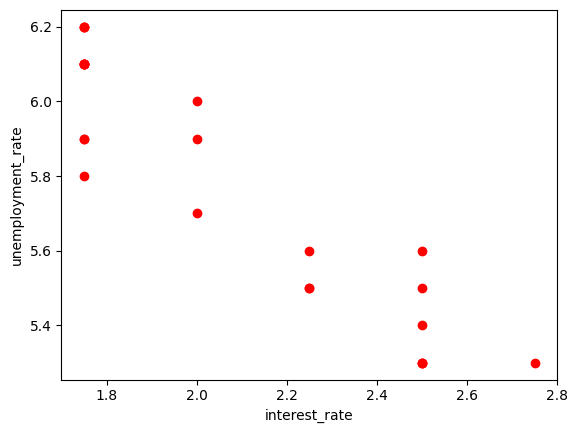

In [77]:
## Visualise datapoints clearly
plt.scatter(df_index['interest_rate'],df_index['unemployment_rate'],color='r')
plt.xlabel('interest_rate')
plt.ylabel("unemployment_rate")

In [78]:
## independent and dependent features
X=df_index.iloc[:,:-1]# all rows , all columns except last
y=df_index.iloc[:,-1]# all rows, only last column

In [79]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [80]:
y.head()

0    1464
1    1394
2    1357
3    1293
4    1256
Name: index_price, dtype: int64

In [81]:
# train test split
from sklearn.model_selection import train_test_split


In [82]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [83]:
import seaborn as sns

<Axes: xlabel='interest_rate', ylabel='index_price'>

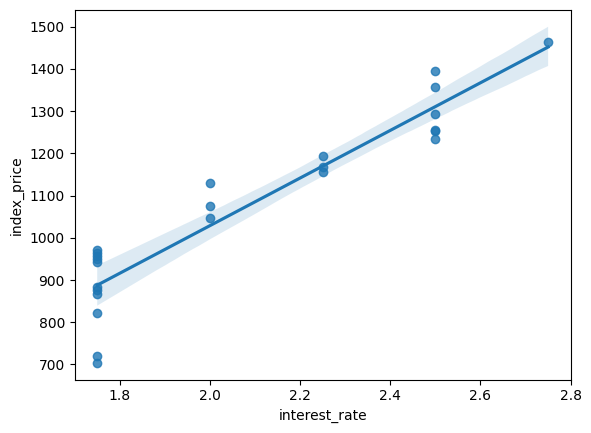

In [84]:
sns.regplot(data=df_index,x='interest_rate',y='index_price')

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

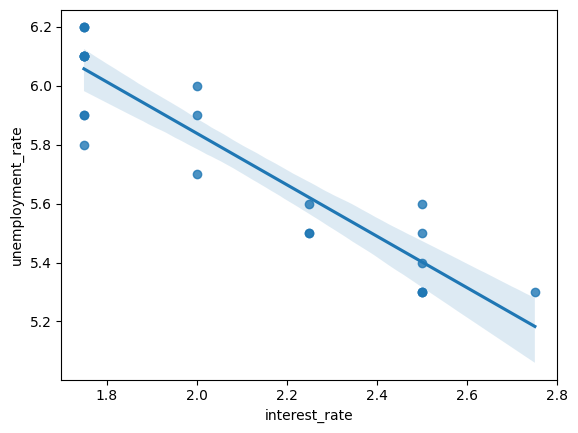

In [85]:
sns.regplot(data=df_index,x='interest_rate',y='unemployment_rate')

<Axes: xlabel='unemployment_rate', ylabel='index_price'>

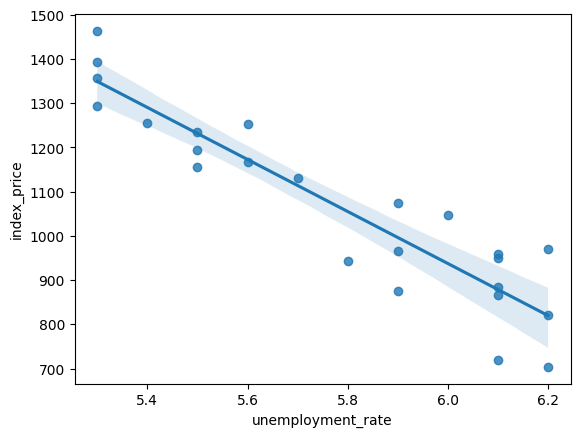

In [86]:
sns.regplot(data=df_index,x='unemployment_rate',y='index_price')

In [87]:
from sklearn.preprocessing import StandardScaler

In [88]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [89]:
X_test

array([[ 0.57346234, -0.8615569 ],
       [-0.90115511,  1.30956648],
       [ 2.0480798 , -1.48187786],
       [-0.90115511,  0.999406  ],
       [-0.16384638,  0.37908503],
       [ 0.57346234, -0.55139641]])

In [90]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()

In [91]:
regression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [92]:
## Cross validation
from sklearn.model_selection import cross_val_score 
validation_score=cross_val_score(regression,X_train,y_train,scoring='neg_mean_squared_error',cv=3)

In [93]:
validation_score

array([-4931.75998049, -7678.92481762, -5140.16280004])

In [94]:
np.mean(validation_score)

np.float64(-5916.949199383535)

In [95]:
## Prediction
y_pred=regression.predict(X_test)

In [96]:
y_pred

array([1204.11480076,  821.6799308 , 1406.43805112,  857.70225472,
        994.88620382, 1168.09247684])

In [97]:
## Performance metrics
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [98]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

5839.313388221632
60.41680619116719
76.41540020324196


In [99]:
from sklearn.metrics import r2_score

In [100]:
score=r2_score(y_true=y_test,y_pred=y_pred)
score

0.8263500205473799

In [101]:
adj_r2_score=1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
adj_r2_score

0.7105833675789666

### Assumptions

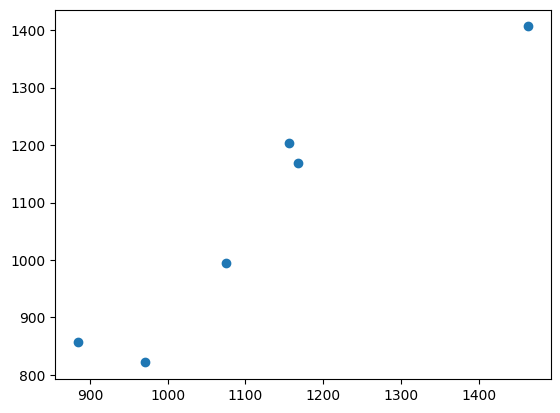

In [103]:
plt.scatter(y_test,y_pred)

Since they have a linear relationship that means the model has worked well

In [104]:
residuals=y_test-y_pred
print(residuals)

8     -48.114801
16    149.320069
0      57.561949
18     26.297745
11     80.113796
9      -1.092477
Name: index_price, dtype: float64


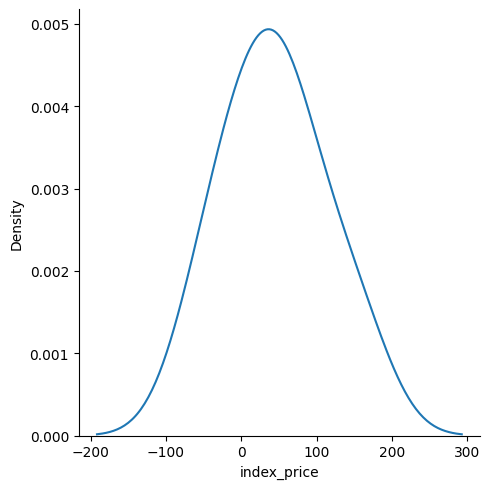

In [105]:
## Plot the residuals
sns.displot(residuals,kind='kde')## kde is kernel density estimator

This kind of curve means the model is working well

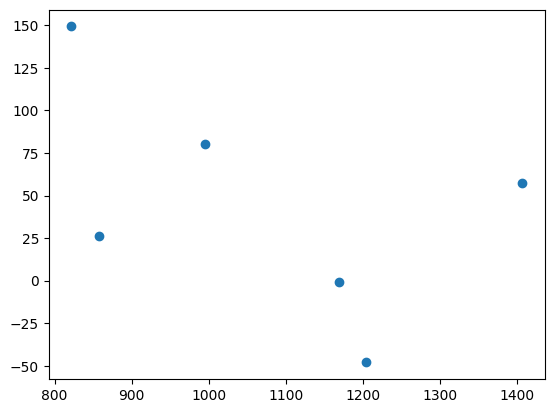

In [106]:
## scatter plot with respect to prediction and residuals
plt.scatter(y_pred,residuals)

Residuals are uniformly distributed and not following a pattern so that means the model is working well.

In [107]:
## OLS Linear Regression
import statsmodels.api as sm
model=sm.OLS(y_train,X_train).fit()

In [108]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Thu, 05 Feb 2026   Prob (F-statistic):                       0.754
Time:                        15:12:30   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            88.3474    658.261      0.134      0.895   -1307.103    1483.798
x2          -116.1409    658.261     -0.176      0.862   -1511.591    1279.309
==============================================================================
Omnibus:                        0.595   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.743   Jarque-Bera (JB):                0.565
Skew:                          -0.360   Prob(JB):                        0.754
Kurtosis:                       2.516   Cond. No.                         4.78
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [109]:
regression.coef_

array([  88.34738929, -116.14092041])

Both the coefficient values are same for LR and OLS